# End-to-End Machine Learning Exercise


**Prepared by:** **Ali H. El-Kassas**  
*Senior Data Scientist | Machine Learning Instructor*

This notebook is intended to help students practice the complete machine learning workflow, including exploratory data analysis, data preprocessing, feature engineering, model training, hyperparameter tuning, and error analysis.

Complete all `TODO` sections.

### Objectives

Build a machine learning pipeline that predicts the Manufacturer Suggested Retail Price (MSRP) of a car.

- Frame the problem
- Select a Performance Measure
- Quick look on the data
- Train/Validation/Test split
- EDA
- Preprocessing
- Pipelines
- Modeling
- Fine-Tuning
- Error Analysis
- Final Evaluation
- Deploy the model

In [1]:
# TODO Import all the lib that you need here
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeRegressor

In [2]:
# TODO: Load the dataset
cars = pd.read_csv("data.csv")

## Initial Inspection
Inspect shape, dtypes, missing values, duplicates and descriptive statistics.

In [3]:
# TODO
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5

In [4]:
# TODO
cars.shape

(11914, 16)

In [5]:
# TODO
cars.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [6]:
# TODO
cars.describe()

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
count,11914.000000,11845.00000,11884.000000,11908.000000,11914.000000,11914.000000,11914.000000,1.191400e+04
mean,2010.384338,249.38607,5.628829,3.436093,26.637485,19.733255,1554.911197,4.059474e+04
std,7.579740,109.19187,1.780559,0.881315,8.863001,8.987798,1441.855347,6.010910e+04
min,1990.000000,55.00000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,170.00000,4.000000,2.000000,22.000000,16.000000,549.000000,2.100000e+04
50%,2015.000000,227.00000,6.000000,4.000000,26.000000,18.000000,1385.000000,2.999500e+04
75%,2016.000000,300.00000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.223125e+04
max,2017.000000,1001.00000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06


In [7]:
# TODO
cars.isnull().sum()

Make                    0
Model                   0
Year                    0
Engine Fuel Type        3
Engine HP              69
Engine Cylinders       30
Transmission Type       0
Driven_Wheels           0
Number of Doors         6
Market Category      3742
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64

## Train / Validation / Test Split
Split data into Train, Validation and Test sets.

In [8]:
# TODO
x = cars.drop(columns = 'MSRP')
y = cars['MSRP']


x_train_val, x_test, y_train_val, y_test = train_test_split(x, y, test_size = .2, random_state = 500)


x_train, x_val, y_train, y_val = train_test_split(x_train_val, y_train_val, test_size = .2, random_state = 500)

## Exploratory Data Analysis

### Numerical Features



- Histograms
- KDE plots
- Boxplots
- Distribution of MSRP
- Identify skewed features

<Figure size 40000x10000 with 0 Axes>

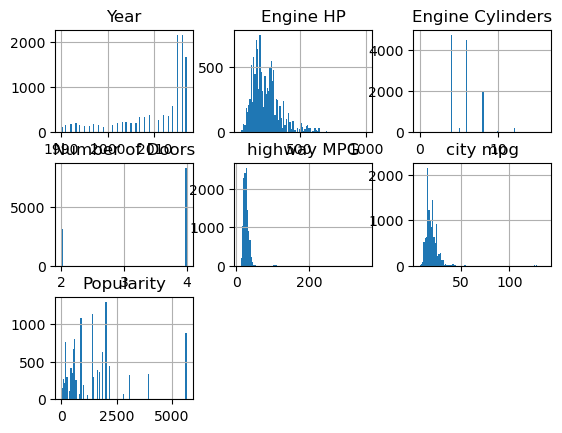

In [9]:
# TODO

import matplotlib.pyplot as plt

plt.figure(figsize = (400, 100))
x.hist(bins = 100);

## Outlier Detection


- Identify outliers using boxplots
- Decide whether to remove them and explain why?

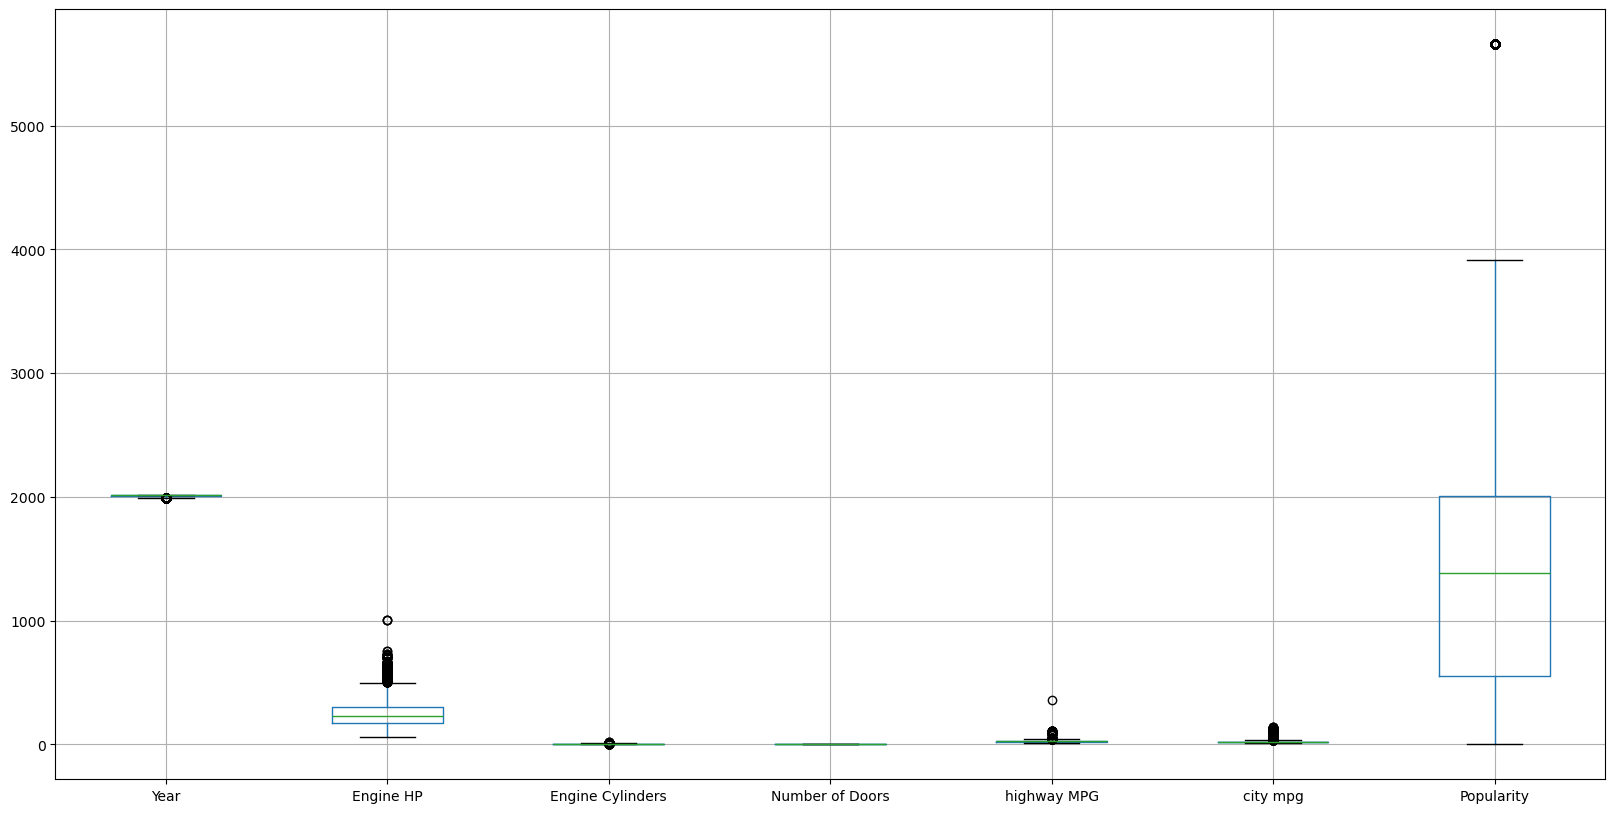

In [10]:
# TODO
plt.figure(figsize = (20, 10))
x.boxplot();

- We have the outlier in Engine HP, highway MGP, & City mpg.
- We can use the MinMaxScaler to make the number near & semilar.
- we can remove the outlier.

### Categorical Features



- Countplots
- Number of unique values

In [34]:
# TODO

categorical_cols = x_train.select_dtypes(include=['object']).columns
unique_values = x_train[categorical_cols].nunique().sort_values(ascending=False)
unique_values

Model                880
Market Category       67
Make                  48
Vehicle Style         16
Engine Fuel Type       9
Transmission Type      5
Driven_Wheels          4
Vehicle Size           3
dtype: int64

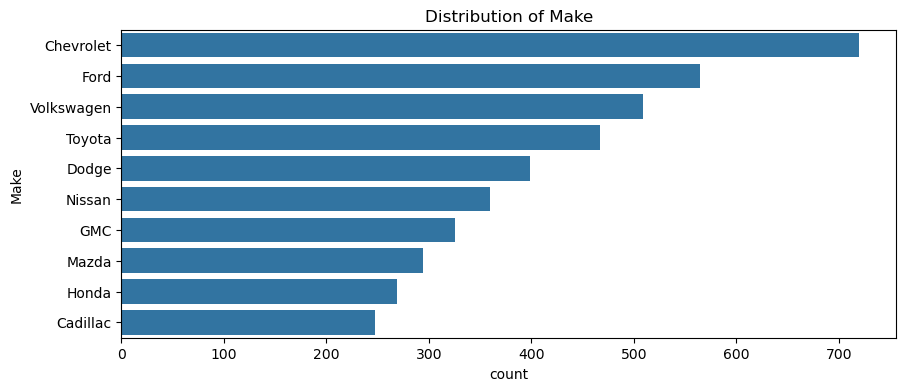

In [12]:
import seaborn as sns

cat_cols = x_train.select_dtypes(include = ['object']).columns
plt.figure(figsize = (10, 4))
sns.countplot(data = x_train, y = cat_cols[0], order = x_train[cat_cols[0]].value_counts().index[:10])
plt.title(f"Distribution of {cat_cols[0]}")
plt.show()

### Relationship with Target

Tasks

- Scatterplots
- Correlation heatmap
- Pairplots (selected columns)


In [13]:
import numpy as np

In [14]:
num_cols = x_train.select_dtypes(include = [np.number]).columns.tolist()

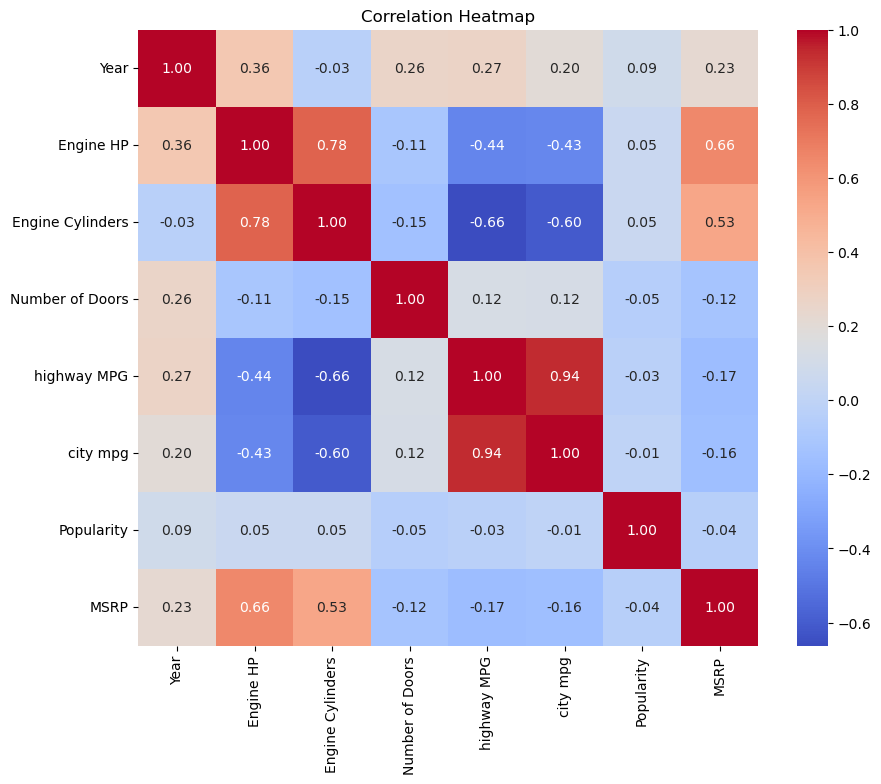

In [15]:
# TODO
plt.figure(figsize = (10, 8))
train_data = x_train.copy()
train_data['MSRP'] = y_train
sns.heatmap(train_data[num_cols + ['MSRP']].corr(), annot = True, cmap = 'coolwarm', fmt = ".2f")
plt.title("Correlation Heatmap")
plt.show()

Questions:

- Which features seem most correlated with price?

In [16]:
# TODO - No Code
# Engine HP is the most corr with MSRP

## Feature Engineering
Create at least two new features that may improve performance.

Possible ideas

- Engine HP per Cylinder

- Power-to-weight proxy


**You should do the same step for the `val` and `test`**

In [17]:
# TODO
cars.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='object')

In [18]:
cars['hp_per_cylinder'] = cars['Engine HP'] / cars['Engine Cylinders']
cars['power_to_weight'] = cars['Engine HP'] / cars['highway MPG']
cars

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP,hp_per_cylinder,power_to_weight
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135,55.833333,12.884615
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650,50.000000,10.714286
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350,50.000000,10.714286
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450,38.333333,8.214286
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500,38.333333,8.214286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120,50.000000,13.043478
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670,50.000000,13.043478
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620,50.000000,13.043478
11912,Acura,ZDX,2013,premium unleaded (recommended),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50920,50.000000,13.043478


## Preprocessing
Identify numerical and categorical columns and build a ColumnTransformer.

In [19]:
# TODO
num_cols = ['Year', 'Engine HP', 'Engine Cylinders', 'Number of Doors', 'highway MPG', 'city mpg', 'Popularity']
cat_cols = ['Make', 'Model', 'Engine Fuel Type', 'Transmission Type', 'Driven_Wheels', 'Market Category', 'Vehicle Size', 'Vehicle Style']

## Pipeline
Create a preprocessing + model pipeline.

In [20]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

In [21]:
# TODO
num_pipe = make_pipeline(
    SimpleImputer(strategy = 'median'),
    MinMaxScaler())

cat_pipe = make_pipeline(
    SimpleImputer(strategy = 'most_frequent'),
    OneHotEncoder(handle_unknown = 'ignore'))

preprocessor = ColumnTransformer(
    transformers = [
        ('num', num_pipe, num_cols),
        ('cat', cat_pipe, cat_cols)])

## Baseline Model
Train a Linear Regression model and evaluate using MAE, RMSE and MSE.

In [22]:
from sklearn.linear_model import LinearRegression

baseline_pipe = make_pipeline(preprocessor, LinearRegression())
baseline_pipe.fit(x_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('minmaxscaler',
                                                                   MinMaxScaler())]),
                                                  ['Year', 'Engine HP',
                                                   'Engine Cylinders',
                                                   'Number of Doors',
                                                   'highway MPG', 'city mpg',
                                                   'Popularity']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Make', 'Model',
                                                   'Engine Fuel Type',
                                                   'Transmission Type',
                                                   'Driven_Wheels',
                                                   'Market Category',
                                                   'Vehicle Size',
                                                   'Vehicle Style'])])),
                ('linearregression', LinearRegression())])

In [23]:
# TODO
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

y_pred_val = baseline_pipe.predict(x_val)

mae = mean_absolute_error(y_val, y_pred_val)
mse = mean_squared_error(y_val, y_pred_val)
rmse = np.sqrt(mse)

print(f"Linear Regression Validation MAE: {mae:.2f}")
print(f"Linear Regression Validation RMSE: {rmse:.2f}")
print(f"Linear Regression Validation MSE: {mse:.2f}")

Linear Regression Validation MAE: 4690.85
Linear Regression Validation RMSE: 29961.86
Linear Regression Validation MSE: 897713151.97


How well does Linear Regression perform?

In [24]:
# TODO 
# The mean squared error is considered very large, and It is not suitable for linear relationships

## Model Comparison
Compare at least two regression models.

In [25]:
# TODO
cars_pipe = make_pipeline(preprocessor, DecisionTreeRegressor(random_state = 42))

cars_pipe.fit(x_train, y_train)

cars_mae = mean_absolute_error(y_val, cars_pipe.predict(x_val))

print(f"Decision Tree Val MAE: {cars_mae:.2f}")

Decision Tree Val MAE: 4322.15


In [31]:
from sklearn.linear_model import LinearRegression

full_pipe = make_pipeline(preprocessor, DecisionTreeRegressor())
full_pipe.fit(x_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('minmaxscaler',
                                                                   MinMaxScaler())]),
                                                  ['Year', 'Engine HP',
                                                   'Engine Cylinders',
                                                   'Number of Doors',
                                                   'highway MPG', 'city mpg',
                                                   'Popularity']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Make', 'Model',
                                                   'Engine Fuel Type',
                                                   'Transmission Type',
                                                   'Driven_Wheels',
                                                   'Market Category',
                                                   'Vehicle Size',
                                                   'Vehicle Style'])])),
                ('decisiontreeregressor', DecisionTreeRegressor())])

## Hyperparameter Tuning
Tune your best model using GridSearchCV.

In [32]:
# TODO
from sklearn.model_selection import GridSearchCV

grid = {'decisiontreeregressor__max_depth': [5, 6, 15, 10],
        'decisiontreeregressor__max_leaf_nodes': [2, 5, 10] 
       }

model = GridSearchCV(full_pipe, grid)

model.fit(x_train, y_train)

GridSearchCV(estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('minmaxscaler',
                                                                                          MinMaxScaler())]),
                                                                         ['Year',
                                                                          'Engine '
                                                                          'HP',
                                                                          'Engine '
                                                                          'Cylinders',
                                                                          'Number '
                                                                          'of '
                                                                          'Doors',
                                                                          'highway '
                                                                          'MPG',
                                                                          'city '
                                                                          'mpg',
                                                                          'Popularity']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleI...
                                                                                         ('onehotencoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Make',
                                                                          'Model',
                                                                          'Engine '
                                                                          'Fuel '
                                                                          'Type',
                                                                          'Transmission '
                                                                          'Type',
                                                                          'Driven_Wheels',
                                                                          'Market '
                                                                          'Category',
                                                                          'Vehicle '
                                                                          'Size',
                                                                          'Vehicle '
                                                                          'Style'])])),
                                       ('decisiontreeregressor',
                                        DecisionTreeRegressor())]),
             param_grid={'decisiontreeregressor__max_depth': [5, 6, 15, 10],
                         'decisiontreeregressor__max_leaf_nodes': [2, 5, 10]})

Repeat using RandomizedSearchCV.

In [35]:
# TODO
from sklearn.model_selection import RandomizedSearchCV

grid = {'decisiontreeregressor__max_depth': [5, 6, 15, 10],
        'decisiontreeregressor__max_leaf_nodes': [2, 5, 10] 
       }

model = RandomizedSearchCV(full_pipe, grid)

model.fit(x_train, y_train)

RandomizedSearchCV(estimator=Pipeline(steps=[('columntransformer',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('minmaxscaler',
                                                                                                MinMaxScaler())]),
                                                                               ['Year',
                                                                                'Engine '
                                                                                'HP',
                                                                                'Engine '
                                                                                'Cylinders',
                                                                                'Number '
                                                                                'of '
                                                                                'Doors',
                                                                                'highway '
                                                                                'MPG',
                                                                                'city '
                                                                                'mpg',
                                                                                'Popularity']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                S...
                                                                                               ('onehotencoder',
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['Make',
                                                                                'Model',
                                                                                'Engine '
                                                                                'Fuel '
                                                                                'Type',
                                                                                'Transmission '
                                                                                'Type',
                                                                                'Driven_Wheels',
                                                                                'Market '
                                                                                'Category',
                                                                                'Vehicle '
                                                                                'Size',
                                                                                'Vehicle '
                                                                                'Style'])])),
                                             ('decisiontreeregressor',
                                              DecisionTreeRegressor())]),
                   param_distributions={'decisiontreeregressor__max_depth': [5,
                                                                             6,
                                                                             15,
       

Which method was faster? Did both produce similar results?

In [37]:
# TODO
# It's the same result, & the RandomizedSearchCV is the faster

## Error Analysis (Bonus)

Predict on validation set

In [ ]:
# TODO


Compute residuals

`Actual - Predicted`

In [ ]:
# TODO

Plot residuals, Predicted vs Actual, investigate largest errors.

- Where does the model fail?

In [ ]:
#TODO-NO CODE

Which cars have the highest prediction errors?

In [ ]:
#TODO-NO CODE

Are expensive cars harder to predict?

In [ ]:
#TODO-NO CODE

## Final Test Evaluation
Evaluate **only once** on the held-out test set.

In [38]:
# TODO
y_pred = model.predict(x_test)
mean_absolute_error(y_test, y_pred)

9948.787594120611

## Deployment (Bonus)
Deploy your model using streamlit

## Reflection
Summarize findings.

- Which preprocessing steps were essential?
- Which model performed best?
- Why?
- Did hyperparameter tuning improve performance?
- Which features contributed most?
- What additional data would improve predictions?
- If this model were deployed in production, what challenges might arise?

In [39]:
# TODO
## Reflection
# - Filled missing values and encoded categorical features.
# - Scaled numerical features before training.
# - Decision Tree performed better than Linear Regression.
# - Hyperparameter tuning did not clearly improve performance.
# - Important features: Engine HP, Year, Make, and Model.
# - More data (mileage and car condition) could improve predictions.
# - Production challenges: changing car prices, new models, and missing user inputs.

## Bonus Challenges - 1
- Remove outliers and compare. Did performance improve?
  


In [ ]:
#TODO

## Bonus Challenges - 2

Perform feature selection